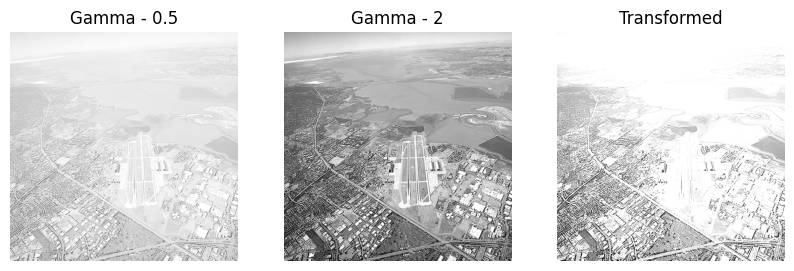

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'


gamma1 = 0.5
gamma2 = 2

gamma1_t = np.array([(i/255) ** gamma1 * 255 for i in np.arange(0, 256)]).astype(np.uint8)
gamma2_t = np.array([(i/255) ** gamma2 * 255 for i in np.arange(0, 256)]).astype(np.uint8)

#(a)
gamma1_new_im = gamma1_t[im]

#(b)
gamma2_new_im = gamma2_t[im]

#(c)
t = np.zeros(256, dtype=np.uint8)
r1 = 0.2
r2 = 0.8

lower = int(r1 * 255)
upper = int(r2 * 255)

for i in range(256):
    if i < lower:
        t[i] = 0
    elif i > upper:
        t[i] = 255
    else:
        t[i] = np.round(((i - lower) / (upper - lower)) * 255).astype(np.uint8)

transformed_im = t[im]

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(gamma1_new_im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Gamma - 0.5')
ax[0].axis('off')

ax[1].imshow(gamma2_new_im, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gamma - 2')
ax[1].axis('off')

ax[2].imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
ax[2].axis('off')
ax[2].set_title('Transformed')

plt.show()